Let us simulate how different policy could impact the 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score


## Introduction

The goal of this notebook is to predict juenile crime using a subset of historical data. 

What will the impact be over the next 5 years, if there was a policy that reduced the use of firearms by 20%.

In [2]:
# load data set
raw_data = pd.read_csv('dataset_1980_2020.csv')
raw_data.rename(columns={"Count": "Year"}, inplace=True)


weapon_columns = ["Firearm", "Knife", "Blunt object", "Personal"]
raw_data['Total'] = raw_data[weapon_columns].sum(axis=1)


In [3]:
# Encode categorical features for modeling
encoder = LabelEncoder()
raw_data["State"] = encoder.fit_transform(raw_data["State"])


In [4]:
recent_years = raw_data[raw_data['Year'] >= 2015]
X = raw_data[['Year'] + weapon_columns]  # Features: Year, weapon usage counts
y = raw_data['Total']  # Target: Total juvenile crime count
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


The models that we will use include: linear regression, decision tree, random forest, and gradient boosting

In [5]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

model_results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Predict on test set
    mae = mean_absolute_error(y_test, y_pred)  # Calculate MAE
    r2 = r2_score(y_test, y_pred)  # Calculate R2 score
    
    model_results[model_name] = {
        'model': model,
        'mae': mae,
        'r2': r2,
        'predictions': y_pred
    }
    
    print(f"{model_name}: MAE = {mae:.2f}, R2 = {r2:.2f}")


Linear Regression: MAE = 0.00, R2 = 1.00
Decision Tree: MAE = 2.06, R2 = 0.98
Random Forest: MAE = 1.15, R2 = 1.00
Gradient Boosting: MAE = 0.87, R2 = 1.00


Predicting Future Weapon Usage using a Random forest regressor

In [6]:
from sklearn.ensemble import RandomForestRegressor

# Fit a Random Forest model for each weapon type
weapon_models = {}  # To store the models for each weapon type
future_years = np.arange(2021, 2026).reshape(-1, 1)  # Years for future predictions
future_data = pd.DataFrame({'Year': future_years.flatten()})  # DataFrame to hold future predictions

# Loop through each weapon type and predict its usage for 2021-2025
for weapon in weapon_columns:
    weapon_model = RandomForestRegressor(n_estimators=100, random_state=42)  # Initialize the Random Forest model
    weapon_model.fit(recent_years[['Year']], recent_years[weapon])  # Train the model for this weapon type
    weapon_models[weapon] = weapon_model  # Save the model for this weapon
    
    # Predict weapon usage for the years 2021 to 2025
    predicted_usage = weapon_model.predict(future_data[['Year']])
    
    # Store predicted usage for the future years
    future_data[weapon] = predicted_usage

# Show the predicted future weapon usage
print(future_data)


   Year   Firearm    Knife  Blunt object  Personal
0  2021  21.11347  1.56371      0.377251  0.473098
1  2022  21.11347  1.56371      0.377251  0.473098
2  2023  21.11347  1.56371      0.377251  0.473098
3  2024  21.11347  1.56371      0.377251  0.473098
4  2025  21.11347  1.56371      0.377251  0.473098


In [7]:
simulated_data = future_data.copy()
simulated_data['Firearm'] *= 0.8  # Apply 20% reduction in firearm usage


In [ ]:
# Define the model features explicitly
model_features = ['Year', 'Firearm', 'Knife', 'Blunt object', 'Personal']

final_future_X = future_data[model_features]  # Use the same features as before
final_simulated_X = simulated_data[model_features]  # Same here for the simulated data

# Predict future crimes for original and simulated scenarios
print("Policy Simulation Results:\n")
for name, result in model_results.items():
    model = result["model"]
    
    # Predictions for the original and simulated scenarios
    pred_original = model.predict(final_future_X)
    pred_policy = model.predict(final_simulated_X)
    
    # Calculate the average predicted crime count and the change in incidents
    avg_original = np.mean(pred_original)
    avg_policy = np.mean(pred_policy)
    change = avg_policy - avg_original

    print(f"{name} - Avg Predicted Crime (Original): {avg_original:.2f}")
    print(f"{name} - Avg Predicted Crime (With Policy): {avg_policy:.2f}")
    print(f"{name} - Change: {change:.2f} incidents\n")


Policy Simulation Results:

Linear Regression - Avg Predicted Crime (Original): 23.53
Linear Regression - Avg Predicted Crime (With Policy): 19.30
Linear Regression - Change: -4.22 incidents

Decision Tree - Avg Predicted Crime (Original): 26.00
Decision Tree - Avg Predicted Crime (With Policy): 18.00
Decision Tree - Change: -8.00 incidents

Random Forest - Avg Predicted Crime (Original): 23.64
Random Forest - Avg Predicted Crime (With Policy): 19.15
Random Forest - Change: -4.49 incidents

Gradient Boosting - Avg Predicted Crime (Original): 23.56
Gradient Boosting - Avg Predicted Crime (With Policy): 19.06
Gradient Boosting - Change: -4.50 incidents



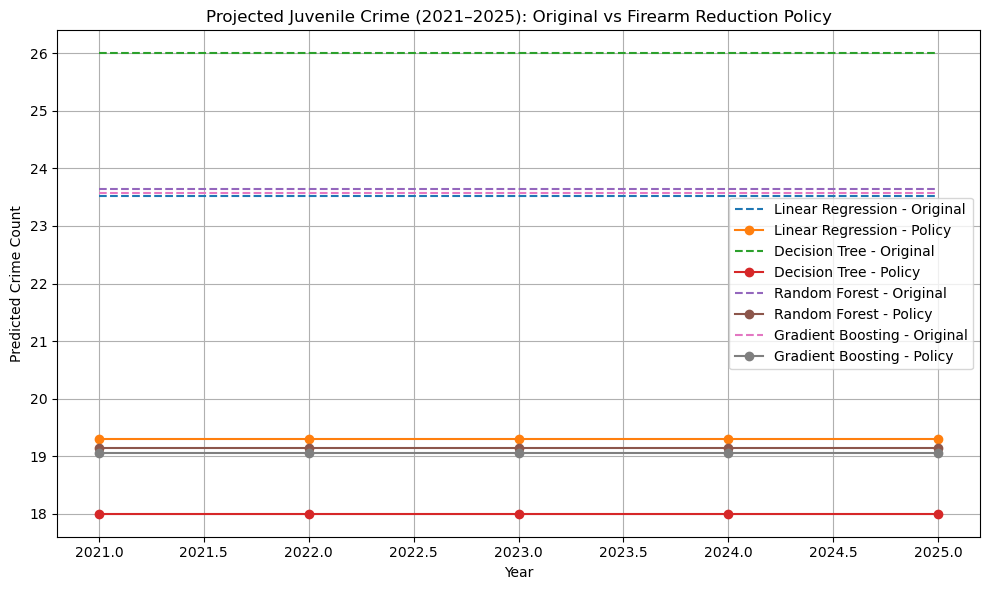

In [10]:
# Plot the results for the original and policy scenarios
plt.figure(figsize=(10, 6))
for name in model_results:
    plt.plot(future_years, model_results[name]['model'].predict(final_future_X), label=f"{name} - Original", linestyle='--')
    plt.plot(future_years, model_results[name]['model'].predict(final_simulated_X), label=f"{name} - Policy", marker='o')

plt.title("Projected Juvenile Crime (2021–2025): Original vs Firearm Reduction Policy")
plt.xlabel("Year")
plt.ylabel("Predicted Crime Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
